In [1]:
import sys

import matplotlib.pyplot as plt
import torch
import torchaudio

from authtransforms.pipeline import Compose, OneOf, SomeOf
from authtransforms.transforms import (
    AddGaussianNoise,
    Normalize,
    RandomApply,
    RandomClip,
    RandomGain,
    RandomPitchShift,
    RandomSpeedChange,
    TimeShift,
    ToMono,
)
from authtransforms.utils import audio_info, compare_audio, compare_play, plot_audio


In [3]:
from pathlib import Path

PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent

audio_path = PROJECT_ROOT / "sample-audio-multilingual/english/real/121_127105_000007_000004.wav"
noise_dir = None

audio, sample_rate = torchaudio.load(audio_path)
print(f"Loaded: {audio_path}")
audio_info(audio, sample_rate, label="Original")


Loaded: /Users/uvieea/Documents/development/authtransforms/sample-audio-multilingual/english/real/121_127105_000007_000004.wav
[Original]
  Shape      : (1, 184080)
  Channels   : 1
  Sample rate: 24000 Hz
  Duration   : 7.670 s  (184080 samples)
  Peak       : 0.4513
  RMS        : 0.0446  (-27.0 dBFS)
  dtype      : torch.float32


/Users/uvieea/Library/Caches/pypoetry/virtualenvs/authtransforms-WaSjjtAv-py3.13/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [4]:
# Base transforms always applied
base_transforms = [
    ToMono(),
    RandomClip(sample_rate=sample_rate, clip_length=sample_rate * 5),  # 5-second clip
    Normalize(target_db=-3.0),
]

# One augmentation chosen randomly from a pool
augmentation_pool = [
    RandomSpeedChange(sample_rate=sample_rate, speed_factors=[0.9, 1.0, 1.1]),
    RandomPitchShift(sample_rate=sample_rate, semitones=(-2, 2)),
    TimeShift(max_shift=0.1),
]

# Extra noise — applied with 50% probability
noise_transforms = [
    RandomApply(AddGaussianNoise(min_amplitude=0.002, max_amplitude=0.01), p=0.5),
]


In [5]:

pipeline = Compose(
    base_transforms
    + [OneOf(augmentation_pool)]
    + noise_transforms
    + [Normalize(target_db=-3.0)]  # re-normalize after mixing
)

print("\nPipeline:")
print(pipeline)


Pipeline:
Compose(
    ToMono(),
    RandomClip(clip_length=120000),
    Normalize(target_db=-3.0),
    OneOf(
    RandomSpeedChange(speed_factors=[0.9, 1.0, 1.1]),
    RandomPitchShift(semitones=(-2, 2)),
    TimeShift(max_shift=0.1, roll=False),
),
    RandomApply(p=0.5, transform=AddGaussianNoise(amplitude=[0.002, 0.01])),
    Normalize(target_db=-3.0),
)


In [7]:

augmented = pipeline(audio)
audio_info(augmented, sample_rate, label="Augmented")


/Users/uvieea/Documents/development/authtransforms/src/authtransforms/transforms.py:77: UserWarning: torchaudio.sox_effects.sox_effects.apply_effects_tensor has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  transformed, _ = torchaudio.sox_effects.apply_effects_tensor(


OSError: dlopen(/Users/uvieea/Library/Caches/pypoetry/virtualenvs/authtransforms-WaSjjtAv-py3.13/lib/python3.13/site-packages/torchaudio/lib/libtorchaudio_sox.so, 0x0006): Library not loaded: @rpath/libsox.dylib
  Referenced from: <00258054-6093-3A0B-BFA5-B917D26370D9> /Users/uvieea/Library/Caches/pypoetry/virtualenvs/authtransforms-WaSjjtAv-py3.13/lib/python3.13/site-packages/torchaudio/lib/libtorchaudio_sox.so
  Reason: tried: '/Users/uvieea/miniconda3/lib/python3.13/lib-dynload/../../libsox.dylib' (no such file), '/Users/uvieea/miniconda3/bin/../lib/libsox.dylib' (no such file)

In [6]:

fig = compare_audio(
    audio,
    augmented,
    sample_rate,
    title_before="Original",
    title_after="Augmented",
)
plt.show()

NameError: name 'augmented' is not defined

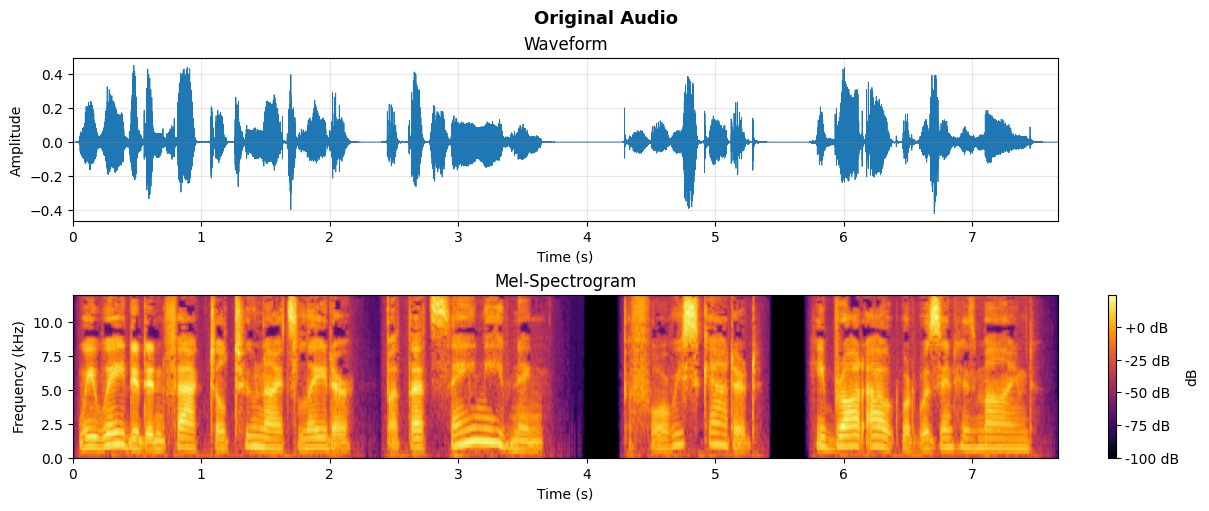

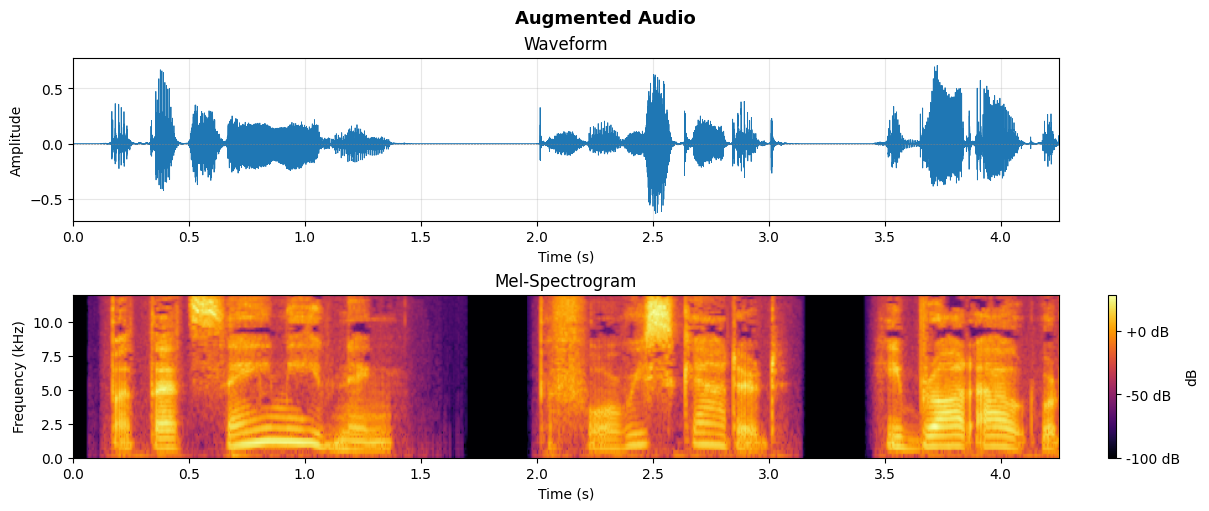

In [7]:
fig_before = plot_audio(audio, sample_rate, title="Original Audio")
fig_after = plot_audio(augmented, sample_rate, title="Augmented Audio")
plt.show()

In [8]:

compare_play(audio, augmented, sample_rate, label_before="Original", label_after="Augmented")


/Users/uvieea/miniconda3/envs/authgenimage/lib/python3.12/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(


In [11]:
play_audio(audio, sample_rate, label="Original")

/Users/uvieea/miniconda3/envs/authgenimage/lib/python3.12/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
